# Statistical analysis — step by step

Goal: test whether accuracy differences between memory backends are statistically significant.

**Correct unit of analysis:** conversation (n=10), not individual question (n=1,540).

Rationale: questions within the same conversation share the same loaded memory — they are not independent observations. Treating 1,540 questions as independent inflates statistical power artificially.

**Paired design:** the same 10 conversations were run on all backends → compare backend A vs B *within* each conversation.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── IEEE-style matplotlib defaults ───────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.framealpha': 0.9,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SINGLE_COL = (3.5, 2.8)
DOUBLE_COL = (7.16, 3.0)

# ── Constants ─────────────────────────────────────────────────────────────────
RESULTS_DIR = Path('../results')
if not any(RESULTS_DIR.glob('*.csv')):
    RESULTS_DIR = Path('../results/backup')
print(f'Loading CSVs from: {RESULTS_DIR.resolve()}')

SCORED_CATEGORIES = {1, 2, 3, 4}
CAT_LABEL = {1: 'single-hop', 2: 'multi-hop', 3: 'temporal', 4: 'open-domain'}
BACKENDS = ['mem0', 'rag', 'full_context', 'graphiti', 'cognee']
COLORS  = {'mem0': '#2563eb', 'rag': '#16a34a', 'full_context': '#ca8a04',
           'graphiti': '#dc2626', 'cognee': '#9333ea'}
HATCHES = {'mem0': '', 'rag': '///', 'full_context': '...', 'graphiti': 'xxx', 'cognee': '\\\\'}
MARKERS = {'mem0': 'o', 'rag': 's', 'full_context': '^', 'graphiti': 'D', 'cognee': 'v'}

# ── Load data ─────────────────────────────────────────────────────────────────
frames = [pd.read_csv(p, dtype={'question': str})
          for p in sorted(RESULTS_DIR.glob('*.csv')) if p.stat().st_size > 0]
raw = pd.concat(frames, ignore_index=True)

constrained = (
    (raw['toxic_latency'].fillna(0) > 0) |
    (raw['toxic_jitter'].fillna(0) > 0) |
    (raw['toxic_bandwidth'].fillna(0) > 0)
)
raw['regime'] = constrained.map({True: 'constrained', False: 'unconstrained'})
raw['correct'] = (raw['judge_verdict'] == 'CORRECT').astype(float)

df = raw[(raw['phase'] == 'ask') & (raw['question_category'].isin(SCORED_CATEGORIES))].copy()

print(f'Ask rows scored: {len(df)}')
print(f'Backends: {sorted(df["memory"].unique())}')
print(f'Conversations: {sorted(df["conversation_index"].unique())}')
print(f'Regimes: {sorted(df["regime"].unique())}')

Loading CSVs from: /home/jacobbista/Documents/RM&SW/Experiment/dmas-long-context-memory/testbed/experiments/results/backup
Ask rows scored: 15400
Backends: ['cognee', 'full_context', 'graphiti', 'mem0', 'rag']
Conversations: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Regimes: ['constrained', 'unconstrained']


## Step 1 — Per-conversation accuracy

Compute accuracy for each (backend, conversation, regime) combination.
This is the dataset all subsequent tests operate on.

In [2]:
per_conv = (
    df.groupby(['memory', 'regime', 'conversation_index'])
      .agg(correct=('correct', 'sum'), n=('correct', 'count'))
      .assign(acc=lambda x: x['correct'] / x['n'])
      .reset_index()
)

unc = per_conv[per_conv['regime'] == 'unconstrained']
pivot = unc.pivot(index='conversation_index', columns='memory', values='acc')
pivot = pivot[BACKENDS]

print('Accuracy per conversation (unconstrained):')
print(pivot.to_string(float_format='{:.3f}'.format))
print()
print('Mean and standard deviation:')
print(pivot.agg(['mean', 'std']).to_string(float_format='{:.3f}'.format))

Accuracy per conversation (unconstrained):
memory              mem0   rag  full_context  graphiti  cognee
conversation_index                                            
0                  0.868 0.836         0.809     0.566   0.533
1                  0.840 0.877         0.877     0.642   0.556
2                  0.809 0.816         0.724     0.638   0.645
3                  0.769 0.709         0.759     0.538   0.497
4                  0.713 0.764         0.736     0.556   0.225
5                  0.780 0.772         0.821     0.480   0.569
6                  0.787 0.733         0.733     0.487   0.593
7                  0.822 0.764         0.764     0.508   0.634
8                  0.821 0.744         0.801     0.513   0.571
9                  0.842 0.734         0.690     0.551   0.608

Mean and standard deviation:
memory  mem0   rag  full_context  graphiti  cognee
mean   0.805 0.775         0.771     0.548   0.543
std    0.044 0.052         0.055     0.057   0.120


## Step 2 — Per-conversation ranking

Rank backends within each conversation (rank 1 = highest accuracy).
Shows whether the ranking is consistent across conversations.

In [3]:
ranked = pivot.rank(axis=1, ascending=False).astype(int)
print('Rank per conversation (1 = highest accuracy):')
print(ranked.to_string())
print()
print('Mean rank per backend (lower = better):')
print(ranked.mean().sort_values().to_string(float_format='{:.2f}'.format))
print()
print('Times each backend ranked first:')
print((ranked == 1).sum().sort_values(ascending=False).to_string())

Rank per conversation (1 = highest accuracy):
memory              mem0  rag  full_context  graphiti  cognee
conversation_index                                           
0                      1    2             3         4       5
1                      3    1             1         4       5
2                      2    1             3         5       4
3                      1    3             2         4       5
4                      3    1             2         4       5
5                      2    3             1         5       4
6                      1    2             2         5       4
7                      1    2             2         5       4
8                      1    3             2         5       4
9                      1    2             3         5       4

Mean rank per backend (lower = better):
memory
mem0           1.60
rag            2.00
full_context   2.10
cognee         4.40
graphiti       4.60

Times each backend ranked first:
memory
mem0            6
rag

## Step 3 — Paired Wilcoxon signed-rank test (unconstrained, n=10)

Non-parametric test: does not assume normally distributed differences (appropriate for n=10).

H0: the median of pairwise differences is zero (two backends are equivalent).
α = 0.05. All 10 pairs tested.

In [4]:
def paired_wilcoxon(a_vals, b_vals, label_a, label_b):
    """Paired Wilcoxon signed-rank test on per-conversation accuracy arrays."""
    diff = a_vals - b_vals
    if (diff == 0).all():
        return dict(comparison=f'{label_a} vs {label_b}',
                    mean_diff=0, W=0, p=1.0, sig=False)
    W, p = stats.wilcoxon(a_vals, b_vals)
    return dict(
        comparison=f'{label_a} vs {label_b}',
        mean_diff=float(diff.mean()),
        W=float(W),
        p=float(p),
        sig=bool(p < 0.05)
    )

comparisons = [
    ('mem0', 'rag'),
    ('mem0', 'full_context'),
    ('mem0', 'graphiti'),
    ('mem0', 'cognee'),
    ('rag', 'full_context'),
    ('rag', 'graphiti'),
    ('rag', 'cognee'),
    ('full_context', 'graphiti'),
    ('full_context', 'cognee'),
    ('graphiti', 'cognee'),
]

results = []
for a, b in comparisons:
    results.append(paired_wilcoxon(pivot[a].values, pivot[b].values, a, b))

tab = pd.DataFrame(results)
tab['sig_label'] = tab['sig'].map({True: '** SIG **', False: 'n.s.'})
print('Paired Wilcoxon signed-rank (n=10 conversations, unconstrained):')
print(tab[['comparison','mean_diff','W','p','sig_label']].to_string(
    index=False, float_format='{:.4f}'.format))

Paired Wilcoxon signed-rank (n=10 conversations, unconstrained):
              comparison  mean_diff       W      p sig_label
             mem0 vs rag     0.0303 10.0000 0.0840      n.s.
    mem0 vs full_context     0.0337 12.0000 0.1309      n.s.
        mem0 vs graphiti     0.2573  0.0000 0.0020 ** SIG **
          mem0 vs cognee     0.2621  0.0000 0.0020 ** SIG **
     rag vs full_context     0.0034 13.0000 0.9375      n.s.
         rag vs graphiti     0.2271  0.0000 0.0020 ** SIG **
           rag vs cognee     0.2319  0.0000 0.0020 ** SIG **
full_context vs graphiti     0.2237  0.0000 0.0020 ** SIG **
  full_context vs cognee     0.2285  0.0000 0.0020 ** SIG **
      graphiti vs cognee     0.0048 21.0000 0.5566      n.s.


## Step 4 — Visualization: accuracy per conversation (unconstrained)

Line plot: each backend across 10 conversations.
Boxplot: distribution per backend — IQR, median, outliers.

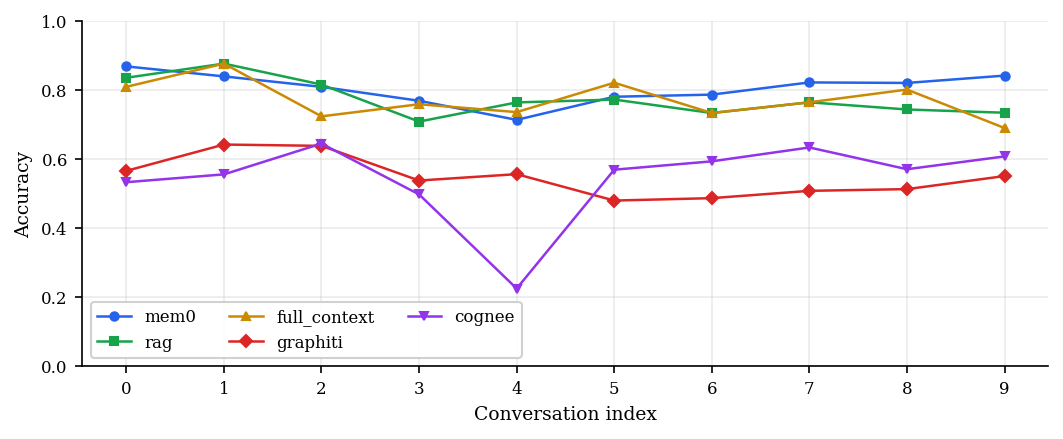

/tmp/ipykernel_249932/3719061634.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=BACKENDS, patch_artist=True, widths=0.5)


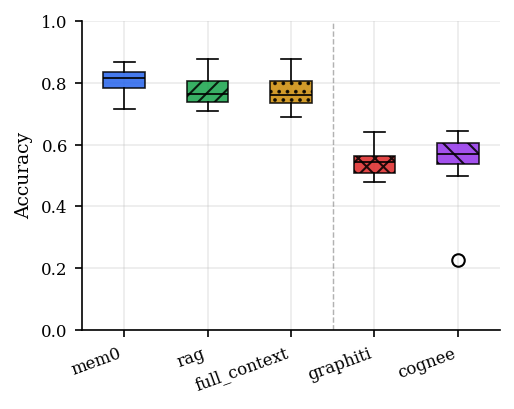

In [5]:
x = pivot.index.astype(int)

# ── line plot per conversation (unconstrained) — notebook only ────────────────
fig, ax = plt.subplots(figsize=DOUBLE_COL)
for mem in BACKENDS:
    ax.plot(x, pivot[mem].values, marker=MARKERS[mem], label=mem,
            color=COLORS[mem], linewidth=1.2, markersize=4)
ax.set_xlabel('Conversation index')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_ylim(0, 1)
ax.legend(ncol=3)
plt.tight_layout()
plt.savefig('figures/fig_accuracy_per_conv_unconstrained.pdf', bbox_inches='tight')
plt.show()

# ── PAPER FIGURE: boxplot (unconstrained) ────────────────────────────────────
fig, ax = plt.subplots(figsize=SINGLE_COL)
data = [pivot[mem].values for mem in BACKENDS]
bp = ax.boxplot(data, labels=BACKENDS, patch_artist=True, widths=0.5)
for patch, mem in zip(bp['boxes'], BACKENDS):
    patch.set_facecolor(COLORS[mem])
    patch.set_hatch(HATCHES[mem])
    patch.set_alpha(0.85)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)
for element in ['whiskers', 'caps', 'medians', 'fliers']:
    plt.setp(bp[element], color='black', linewidth=0.8)

# cluster separator: dashed vertical line between full_context (3) and graphiti (4)
ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)

# If cognee conv-4 failure persists after re-run, uncomment:
# outlier_val = pivot.loc[4, 'cognee']
# cognee_idx = BACKENDS.index('cognee') + 1
# ax.annotate('conv. 4', xy=(cognee_idx, outlier_val),
#             xytext=(cognee_idx - 1.2, outlier_val - 0.06),
#             fontsize=7, color='#9333ea',
#             arrowprops=dict(arrowstyle='->', color='#9333ea', lw=0.9))

ax.set_ylabel('Accuracy')
ax.set_xticklabels(BACKENDS, rotation=20, ha='right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/fig_accuracy_boxplot_unconstrained.pdf', bbox_inches='tight')
plt.show()

## Step 5 — Constrained network analysis

Same structure as Steps 3–4 but for the constrained regime.
Last block: delta (constrained − unconstrained) per backend — checks whether network constraints affect accuracy.

Mean accuracy per backend (constrained):
memory
mem0           0.809
rag            0.781
full_context   0.761
cognee         0.571
graphiti       0.560

Std per backend (constrained):
memory
mem0           0.040
rag            0.048
full_context   0.062
graphiti       0.052
cognee         0.041

Paired Wilcoxon signed-rank (n=10 conversations, constrained):
              comparison  mean_diff       W      p sig_label
             mem0 vs rag     0.0285  7.0000 0.0742      n.s.
    mem0 vs full_context     0.0486  3.0000 0.0195 ** SIG **
        mem0 vs graphiti     0.2494  0.0000 0.0020 ** SIG **
          mem0 vs cognee     0.2386  0.0000 0.0020 ** SIG **
     rag vs full_context     0.0201 11.0000 0.3828      n.s.
         rag vs graphiti     0.2209  0.0000 0.0020 ** SIG **
           rag vs cognee     0.2101  0.0000 0.0020 ** SIG **
full_context vs graphiti     0.2007  0.0000 0.0020 ** SIG **
  full_context vs cognee     0.1900  0.0000 0.0020 ** SIG **
      graphiti vs cognee    -

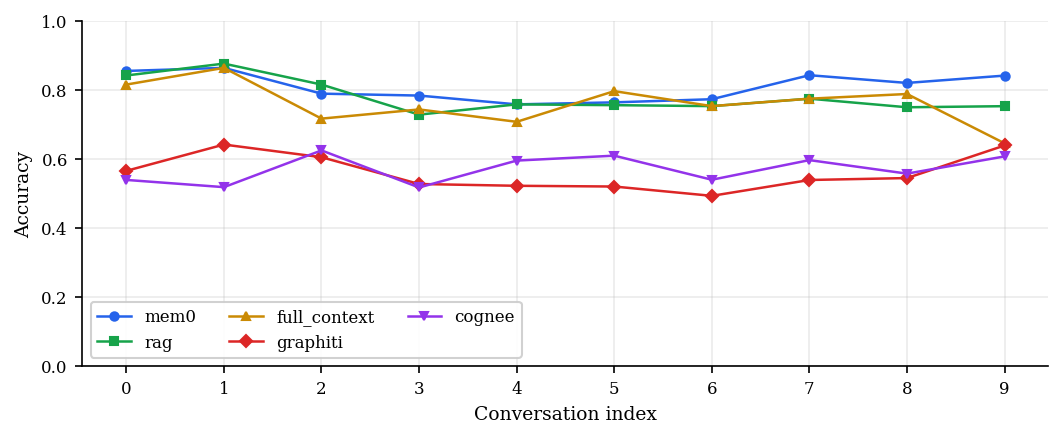

/tmp/ipykernel_249932/2418096100.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_con, labels=BACKENDS, patch_artist=True, widths=0.5)


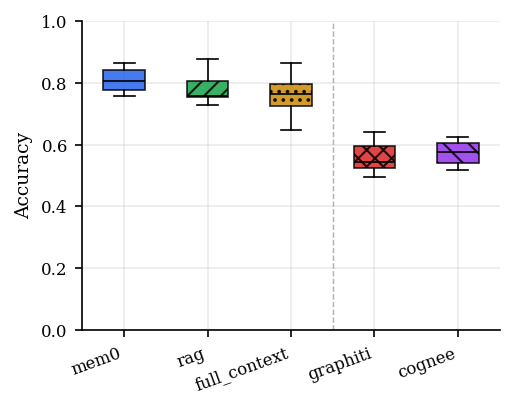


Delta accuracy (constrained − unconstrained), paired Wilcoxon:
  mem0             mean_delta=+0.004  p=0.4609  n.s.
  rag              mean_delta=+0.006  p=0.1094  n.s.
  full_context     mean_delta=-0.011  p=0.1055  n.s.
  graphiti         mean_delta=+0.012  p=0.5469  n.s.
  cognee           mean_delta=+0.028  p=0.9102  n.s.


In [6]:
con = per_conv[per_conv['regime'] == 'constrained']
pivot_con = con.pivot(index='conversation_index', columns='memory', values='acc')[BACKENDS]

print('Mean accuracy per backend (constrained):')
print(pivot_con.mean().sort_values(ascending=False).to_string(float_format='{:.3f}'.format))
print()
print('Std per backend (constrained):')
print(pivot_con.std().to_string(float_format='{:.3f}'.format))
print()

results_con = []
for a, b in comparisons:
    a_vals = pivot_con[a].values
    b_vals = pivot_con[b].values
    results_con.append(paired_wilcoxon(a_vals, b_vals, a, b))

tab_con = pd.DataFrame(results_con)
tab_con['sig_label'] = tab_con['sig'].map({True: '** SIG **', False: 'n.s.'})
print('Paired Wilcoxon signed-rank (n=10 conversations, constrained):')
print(tab_con[['comparison','mean_diff','W','p','sig_label']].to_string(
    index=False, float_format='{:.4f}'.format))

x_con = pivot_con.index.astype(int)

# ── line plot constrained (notebook only) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=DOUBLE_COL)
for mem in BACKENDS:
    ax.plot(x_con, pivot_con[mem].values, marker=MARKERS[mem], label=mem,
            color=COLORS[mem], linewidth=1.2, markersize=4)
ax.set_xlabel('Conversation index')
ax.set_ylabel('Accuracy')
ax.set_xticks(x_con)
ax.set_ylim(0, 1)
ax.legend(ncol=3)
plt.tight_layout()
plt.savefig('figures/fig_accuracy_per_conv_constrained.pdf', bbox_inches='tight')
plt.show()

# ── boxplot constrained (notebook only) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=SINGLE_COL)
data_con = [pivot_con[mem].values for mem in BACKENDS]
bp = ax.boxplot(data_con, labels=BACKENDS, patch_artist=True, widths=0.5)
for patch, mem in zip(bp['boxes'], BACKENDS):
    patch.set_facecolor(COLORS[mem])
    patch.set_hatch(HATCHES[mem])
    patch.set_alpha(0.85)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)
for element in ['whiskers', 'caps', 'medians', 'fliers']:
    plt.setp(bp[element], color='black', linewidth=0.8)
ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_ylabel('Accuracy')
ax.set_xticklabels(BACKENDS, rotation=20, ha='right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/fig_accuracy_boxplot_constrained.pdf', bbox_inches='tight')
plt.show()

print()
print('Delta accuracy (constrained − unconstrained), paired Wilcoxon:')
for mem in BACKENDS:
    u = pivot[mem].values
    c = pivot_con[mem].values
    diff = c - u
    W, p = stats.wilcoxon(c, u) if not (diff == 0).all() else (0, 1.0)
    sig = '** SIG **' if p < 0.05 else 'n.s.'
    print(f'  {mem:15}  mean_delta={diff.mean():+.3f}  p={p:.4f}  {sig}')

## Step 6 — Accuracy by question category

Descriptive only: k/n (acc%) per backend × category.
No significance tests per category — too few questions per conversation (temporal: 5–13/conv).
Results are indicative of experimental trends, not statistically conclusive.

In [7]:
for regime in ['unconstrained', 'constrained']:
    print(f'=== {regime} ===')
    rows = []
    sub_regime = df[df['regime'] == regime]
    for mem in BACKENDS:
        sub = sub_regime[sub_regime['memory'] == mem]
        row = {'backend': mem}
        for cat in [1, 2, 3, 4]:
            cs = sub[sub['question_category'] == cat]
            k = int(cs['correct'].sum())
            n = len(cs)
            row[CAT_LABEL[cat]] = f'{k}/{n} ({100*k/n:.0f}%)'
        k_all = int(sub['correct'].sum())
        n_all = len(sub)
        row['overall'] = f'{k_all}/{n_all} ({100*k_all/n_all:.0f}%)'
        rows.append(row)
    print(pd.DataFrame(rows).set_index('backend').to_string())
    print()

=== unconstrained ===
                 single-hop      multi-hop     temporal    open-domain          overall
backend                                                                                
mem0          206/282 (73%)  234/321 (73%)  52/96 (54%)  743/841 (88%)  1235/1540 (80%)
rag           192/282 (68%)  237/321 (74%)  46/96 (48%)  707/841 (84%)  1182/1540 (77%)
full_context  189/282 (67%)  203/321 (63%)  40/96 (42%)  745/841 (89%)  1177/1540 (76%)
graphiti      150/282 (53%)  159/321 (50%)  38/96 (40%)  490/841 (58%)   837/1540 (54%)
cognee        146/282 (52%)   84/321 (26%)  47/96 (49%)  551/841 (66%)   828/1540 (54%)

=== constrained ===
                 single-hop      multi-hop     temporal    open-domain          overall
backend                                                                                
mem0          206/282 (73%)  235/321 (73%)  51/96 (53%)  751/841 (89%)  1243/1540 (81%)
rag           200/282 (71%)  236/321 (74%)  48/96 (50%)  709/841 (84%)  1193/

## Step 7 — UNKNOWN (IDK) rate per backend

The responder replies verbatim "I don't know based on the given context." when retrieved memories are insufficient.

This is a direct retrieval quality signal — distinct from WRONG answers:
- **WRONG**: backend retrieved something, responder drew the wrong conclusion
- **UNKNOWN**: retrieval returned nothing useful, responder gave up

Analysis: overall rate, per-conversation rate, paired Wilcoxon on UNKNOWN rate.

=== Overall UNKNOWN rate (all categories) ===
      memory        regime    n  correct_pct  wrong_pct  unknown_pct
      cognee   constrained 1540         57.2       17.6         25.2
full_context   constrained 1540         75.4       14.4         10.2
    graphiti   constrained 1540         55.5       18.6         25.9
        mem0   constrained 1540         80.7       10.8          8.5
         rag   constrained 1540         77.5       11.2         11.4
      cognee unconstrained 1540         53.8       16.9         29.3
full_context unconstrained 1540         76.4       13.8          9.7
    graphiti unconstrained 1540         54.4       19.2         26.5
        mem0 unconstrained 1540         80.2       11.0          8.8
         rag unconstrained 1540         76.8       11.8         11.4

=== UNKNOWN rate per conversation (unconstrained) ===
memory              mem0   rag  full_context  graphiti  cognee
conversation_index                                            
0             

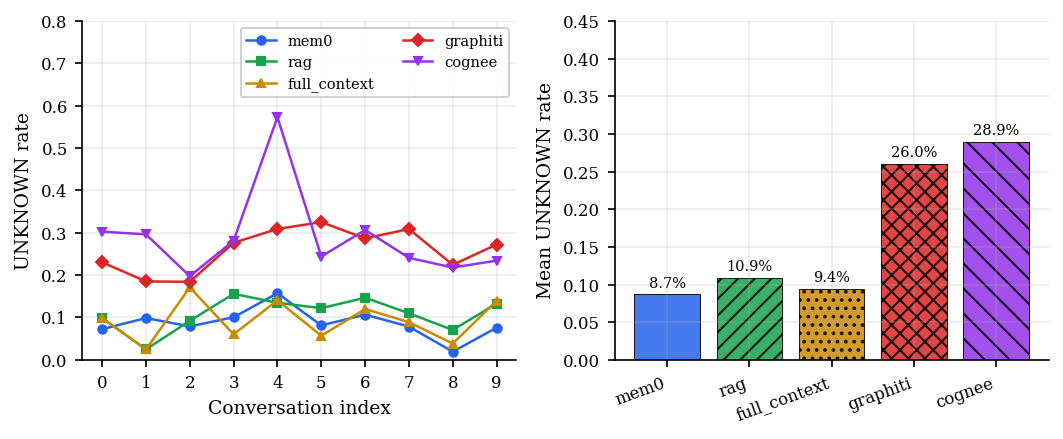


=== Delta UNKNOWN rate (constrained − unconstrained), paired Wilcoxon ===
  mem0             mean_delta=-0.002  p=1.0000  n.s.
  rag              mean_delta=-0.001  p=0.8125  n.s.
  full_context     mean_delta=+0.005  p=0.3828  n.s.
  graphiti         mean_delta=-0.005  p=0.7422  n.s.
  cognee           mean_delta=-0.033  p=0.9219  n.s.


In [8]:
def is_unknown(answer):
    return isinstance(answer, str) and "don't know based on the given context" in answer.lower()

df_ask_all = raw[raw['phase'] == 'ask'].copy()
df_ask_all['unknown'] = df_ask_all['answer'].apply(is_unknown)
df_ask_all['correct'] = (df_ask_all['judge_verdict'] == 'CORRECT').astype(float)

# --- overall UNKNOWN rate per backend × regime ---
print('=== Overall UNKNOWN rate (all categories) ===')
unk_overall = (
    df_ask_all.groupby(['memory', 'regime'])
    .agg(n=('unknown', 'count'),
         unknown=('unknown', 'sum'),
         correct=('correct', 'sum'))
    .assign(unknown_pct=lambda x: 100 * x['unknown'] / x['n'],
            correct_pct=lambda x: 100 * x['correct'] / x['n'],
            wrong_pct=lambda x: 100 * (x['n'] - x['unknown'] - x['correct']) / x['n'])
    .reset_index()
)
print(unk_overall[['memory','regime','n','correct_pct','wrong_pct','unknown_pct']]
      .sort_values(['regime','memory'])
      .to_string(index=False, float_format='{:.1f}'.format))

# --- per-conversation UNKNOWN rate (unconstrained) ---
print()
print('=== UNKNOWN rate per conversation (unconstrained) ===')
unk_per_conv_unc = (
    df_ask_all[df_ask_all['regime'] == 'unconstrained']
    .groupby(['memory', 'conversation_index'])['unknown']
    .mean().rename('unk_rate').reset_index()
)
pivot_unk = unk_per_conv_unc.pivot(
    index='conversation_index', columns='memory', values='unk_rate')[BACKENDS]
print(pivot_unk.to_string(float_format='{:.3f}'.format))
print()
print('Mean UNKNOWN rate per backend (unconstrained):')
print(pivot_unk.mean().sort_values().to_string(float_format='{:.3f}'.format))

# --- Wilcoxon on UNKNOWN rate (unconstrained) ---
print()
print('=== Paired Wilcoxon — UNKNOWN rate (n=10 conv, unconstrained) ===')
unk_results = []
for a, b in comparisons:
    a_vals = pivot_unk[a].values
    b_vals = pivot_unk[b].values
    diff = a_vals - b_vals
    if (diff == 0).all():
        unk_results.append(dict(comparison=f'{a} vs {b}', mean_diff=0, W=0, p=1.0, sig=False))
        continue
    W, p = stats.wilcoxon(a_vals, b_vals)
    unk_results.append(dict(comparison=f'{a} vs {b}',
                            mean_diff=float(diff.mean()),
                            W=float(W), p=float(p), sig=bool(p < 0.05)))
tab_unk = pd.DataFrame(unk_results)
tab_unk['sig_label'] = tab_unk['sig'].map({True: '** SIG **', False: 'n.s.'})
print(tab_unk[['comparison','mean_diff','W','p','sig_label']]
      .to_string(index=False, float_format='{:.4f}'.format))

# ── F3: UNKNOWN rate line + bar (unconstrained) — paper candidate ─────────────
fig, axes = plt.subplots(1, 2, figsize=DOUBLE_COL)

ax = axes[0]
for mem in BACKENDS:
    ax.plot(pivot_unk.index.astype(int), pivot_unk[mem].values,
            marker=MARKERS[mem], label=mem, color=COLORS[mem],
            linewidth=1.2, markersize=4)
ax.set_xlabel('Conversation index')
ax.set_ylabel('UNKNOWN rate')
ax.set_xticks(pivot_unk.index.astype(int))
ax.set_ylim(0, 0.8)
ax.legend(ncol=2, fontsize=7)

ax = axes[1]
means = pivot_unk.mean().reindex(BACKENDS)
bars = ax.bar(range(len(BACKENDS)), means.values,
              color=[COLORS[m] for m in BACKENDS],
              hatch=[HATCHES[m] for m in BACKENDS],
              alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar_label(bars, fmt='{:.1%}', padding=2, fontsize=7)
ax.set_xticks(range(len(BACKENDS)))
ax.set_xticklabels(BACKENDS, rotation=20, ha='right')
ax.set_ylabel('Mean UNKNOWN rate')
ax.set_ylim(0, 0.45)

plt.tight_layout()
plt.savefig('figures/fig_unknown_rate_unconstrained.pdf', bbox_inches='tight')
plt.show()

# --- delta: constrained − unconstrained UNKNOWN rate ---
print()
print('=== Delta UNKNOWN rate (constrained − unconstrained), paired Wilcoxon ===')
unk_per_conv_con = (
    df_ask_all[df_ask_all['regime'] == 'constrained']
    .groupby(['memory', 'conversation_index'])['unknown']
    .mean().rename('unk_rate').reset_index()
)
pivot_unk_con = unk_per_conv_con.pivot(
    index='conversation_index', columns='memory', values='unk_rate')[BACKENDS]

for mem in BACKENDS:
    u = pivot_unk[mem].values
    c = pivot_unk_con[mem].values
    diff = c - u
    if (diff == 0).all():
        print(f'  {mem:15}  mean_delta={diff.mean():+.3f}  p=n/a  (no variation)')
        continue
    W, p = stats.wilcoxon(c, u)
    sig = '** SIG **' if p < 0.05 else 'n.s.'
    print(f'  {mem:15}  mean_delta={diff.mean():+.3f}  p={p:.4f}  {sig}')

## Step 8 — cognee conversation 4 investigation

cognee conv 4: accuracy = 22.5%, UNKNOWN rate = 57.3%. All other backends score 55–76% on the same conversation.

Questions:
1. Is conv 4 structurally different? (session count, turn count, category distribution)
2. Is the collapse cognee-specific or does every backend struggle on conv 4?
3. Which categories drive the UNKNOWN spike in cognee conv 4?
4. Does cognee UNKNOWN rate correlate with conversation size across all 10 conversations?

In [9]:
CAT_LABEL = {1: 'single-hop', 2: 'multi-hop', 3: 'temporal', 4: 'open-domain', 5: 'adversarial'}

df_ask_all['correct'] = (df_ask_all['judge_verdict'] == 'CORRECT').astype(float)
unc_ask = df_ask_all[df_ask_all['regime'] == 'unconstrained']

# --- Q1: conversation structure (load phase) ---
print('=== Q1: Conversation structure (load phase, unconstrained) ===')
load = raw[(raw['phase'] == 'load') & (raw['regime'] == 'unconstrained') & (raw['memory'] == 'mem0')]
conv_stats = load.groupby('conversation_index').agg(
    turns=('question', 'count'),
    sessions=('seed', 'nunique')
).reset_index()
# add question count from ask phase (any backend, same for all)
q_counts = (unc_ask[unc_ask['memory'] == 'mem0']
            .groupby('conversation_index').size().rename('questions'))
conv_stats = conv_stats.set_index('conversation_index').join(q_counts)
conv_stats['q_per_turn'] = conv_stats['questions'] / conv_stats['turns']
print(conv_stats.to_string(float_format='{:.2f}'.format))

# --- Q2: all backends accuracy and UNKNOWN in conv 4 ---
print()
print('=== Q2: All backends on conv 4 (unconstrained) ===')
conv4 = unc_ask[unc_ask['conversation_index'] == 4]
q2 = (conv4.groupby('memory')
      .agg(n=('correct', 'count'),
           correct=('correct', 'sum'),
           unknown=('unknown', 'sum'))
      .assign(acc_pct=lambda x: 100 * x['correct'] / x['n'],
              unk_pct=lambda x: 100 * x['unknown'] / x['n'])
      [['n', 'acc_pct', 'unk_pct']]
      .loc[BACKENDS])
print(q2.to_string(float_format='{:.1f}'.format))

# --- Q3: cognee conv 4 — UNKNOWN by category ---
print()
print('=== Q3: cognee conv 4 — UNKNOWN and accuracy by category ===')
cog4 = conv4[conv4['memory'] == 'cognee'].copy()
cog4['cat_label'] = cog4['question_category'].map(CAT_LABEL)
q3 = (cog4.groupby('cat_label')
      .agg(n=('correct', 'count'),
           correct=('correct', 'sum'),
           unknown=('unknown', 'sum'))
      .assign(acc_pct=lambda x: 100 * x['correct'] / x['n'],
              unk_pct=lambda x: 100 * x['unknown'] / x['n'])
      [['n', 'acc_pct', 'unk_pct']])
print(q3.to_string(float_format='{:.1f}'.format))

# compare with cognee overall (all convs)
print()
print('cognee overall (all convs) by category:')
cog_all = unc_ask[unc_ask['memory'] == 'cognee'].copy()
cog_all['cat_label'] = cog_all['question_category'].map(CAT_LABEL)
q3b = (cog_all.groupby('cat_label')
       .agg(n=('correct', 'count'),
            correct=('correct', 'sum'),
            unknown=('unknown', 'sum'))
       .assign(acc_pct=lambda x: 100 * x['correct'] / x['n'],
               unk_pct=lambda x: 100 * x['unknown'] / x['n'])
       [['n', 'acc_pct', 'unk_pct']])
print(q3b.to_string(float_format='{:.1f}'.format))

# --- Q4: cognee UNKNOWN rate vs conversation size ---
print()
print('=== Q4: cognee UNKNOWN rate vs conversation turn count ===')
cog_unk = (unc_ask[unc_ask['memory'] == 'cognee']
           .groupby('conversation_index')['unknown']
           .mean().rename('unk_rate'))
q4 = conv_stats.join(cog_unk)
print(q4[['turns', 'sessions', 'questions', 'unk_rate']].to_string(float_format='{:.3f}'.format))

corr_turns = q4['turns'].corr(q4['unk_rate'])
corr_questions = q4['questions'].corr(q4['unk_rate'])
print(f'\nCorrelation unk_rate vs turns:     r={corr_turns:.3f}')
print(f'Correlation unk_rate vs questions: r={corr_questions:.3f}')

=== Q1: Conversation structure (load phase, unconstrained) ===
                    turns  sessions  questions  q_per_turn
conversation_index                                        
0                     419        19        152        0.36
1                     369        19         81        0.22
2                     663        32        152        0.23
3                     629        29        199        0.32
4                     680        29        178        0.26
5                     675        28        123        0.18
6                     689        31        150        0.22
7                     681        30        191        0.28
8                     509        25        156        0.31
9                     568        30        158        0.28

=== Q2: All backends on conv 4 (unconstrained) ===
                n  acc_pct  unk_pct
memory                             
mem0          178     71.3     15.7
rag           178     76.4     13.5
full_context  178     73.6     14